In [8]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lmfit.models import GaussianModel, VoigtModel, ConstantModel
from scipy.special import wofz
from pathlib import Path

<h3 style="color: #e19edc;"> Lectura de espectros del 2018</h3>

In [9]:
#Rutas Julio, Agosto y Septiembre

ruta_24_julio = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-07-24.xlsx"
ruta_27_julio = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-07-27.xlsx"
ruta_03_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-08-03.xlsx"
ruta_07_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-08-07.xlsx"
ruta_11_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-08-11.xlsx"
ruta_16_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-08-16.xlsx"
ruta_23_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-08-23.xlsx"
ruta_29_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-08-29.xlsx"
ruta_11_septiembre = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-09-11.xlsx"

In [10]:
#Datos de Julio, Agosto y Septiembre

antares_24_julio = pd.read_excel(ruta_24_julio, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_27_julio = pd.read_excel(ruta_27_julio, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_03_agosto = pd.read_excel(ruta_03_agosto, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_07_agosto = pd.read_excel(ruta_07_agosto, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_11_agosto = pd.read_excel(ruta_11_agosto, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_16_agosto = pd.read_excel(ruta_16_agosto, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_23_agosto = pd.read_excel(ruta_23_agosto, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_29_agosto = pd.read_excel(ruta_29_agosto, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_11_septiembre = pd.read_excel(ruta_11_septiembre, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])

In [11]:
espectros = {
    "antares_24_julio": antares_24_julio,
    "antares_27_julio": antares_27_julio,
    "antares_03_agosto": antares_03_agosto,
    "antares_07_agosto": antares_07_agosto,
    "antares_11_agosto": antares_11_agosto,
    "antares_16_agosto": antares_16_agosto,
    "antares_23_agosto": antares_23_agosto,
    "antares_29_agosto": antares_29_agosto,
    "antares_11_septiembre": antares_11_septiembre,
}

<h4 style="color: #e19edc;"> Parámetros de la normalización con el método Sigma - Clipping</h4>

In [20]:
guardar_graficos = True   
carpeta_graficos = "./Graficas 2018/Espectros_normalizados"  
 
col_longitud_onda = "Longitud onda"
col_flujo = "Flujo"
 
grado_polinomio= 2     
N_iteraciones = 10
sigma_corte = 2.0

<h5 style="color: #e19edc;"> Modelo</h5>

In [21]:
def ajustar_continuo(longitud_onda, flujo, grado, n_iter, sigma):

    longitud_onda = np.asarray(longitud_onda, dtype=float)
    flujo = np.asarray(flujo, dtype=float)
 
    mascara = np.ones_like(flujo, dtype=bool)
 
    for _ in range(n_iter):
        coef = np.polyfit(longitud_onda[mascara], flujo[mascara], deg=grado)
        continuo_iter = np.polyval(coef, longitud_onda)
 
        residuo = flujo - continuo_iter
        
        mediana = np.median(residuo[mascara])
        mad = np.median(np.abs(residuo[mascara] - mediana))
        mad_std = mad * 1.4826

        umbral_superior = mediana + sigma * mad_std
        umbral_inferior = mediana - sigma * mad_std
        nueva_mascara = (residuo > umbral_inferior) & (residuo < umbral_superior)
 
        if nueva_mascara.sum() < grado + 2:
            break

        if np.array_equal(nueva_mascara, mascara):
            break
 
        mascara = nueva_mascara
 
    coef_final = np.polyfit(longitud_onda[mascara], flujo[mascara], deg=grado)
    continuo = np.polyval(coef_final, longitud_onda)
 
    return continuo, mascara


<h5 style="color: #e19edc;"> Verificación del modelo con gráficos</h5>


Procesando: antares_24_julio
  Puntos totales: 203
  Puntos excluidos: 51
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_24_julio_control.png


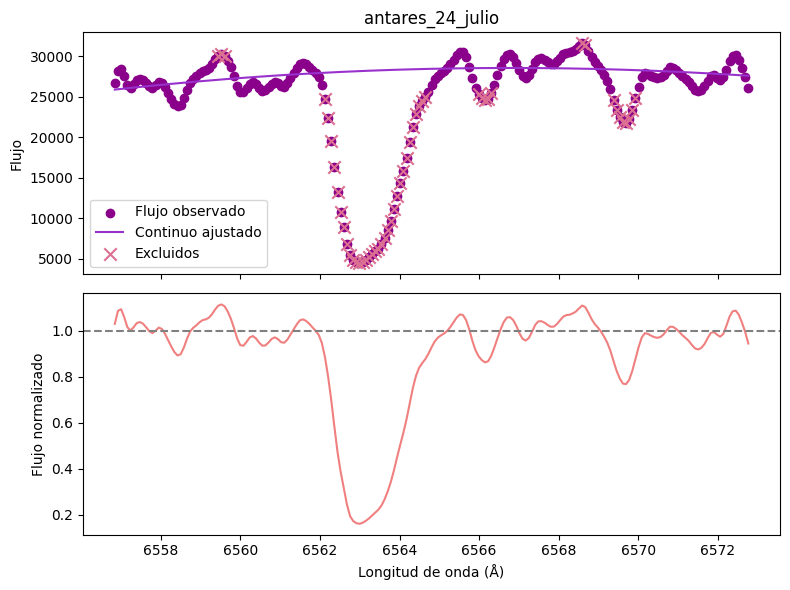


Procesando: antares_27_julio
  Puntos totales: 158
  Puntos excluidos: 68
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_27_julio_control.png


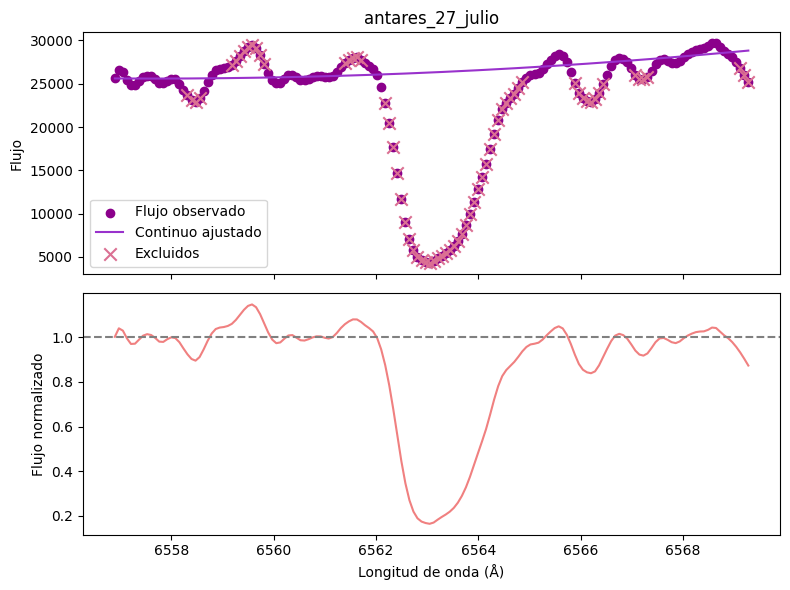


Procesando: antares_03_agosto
  Puntos totales: 161
  Puntos excluidos: 44
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_03_agosto_control.png


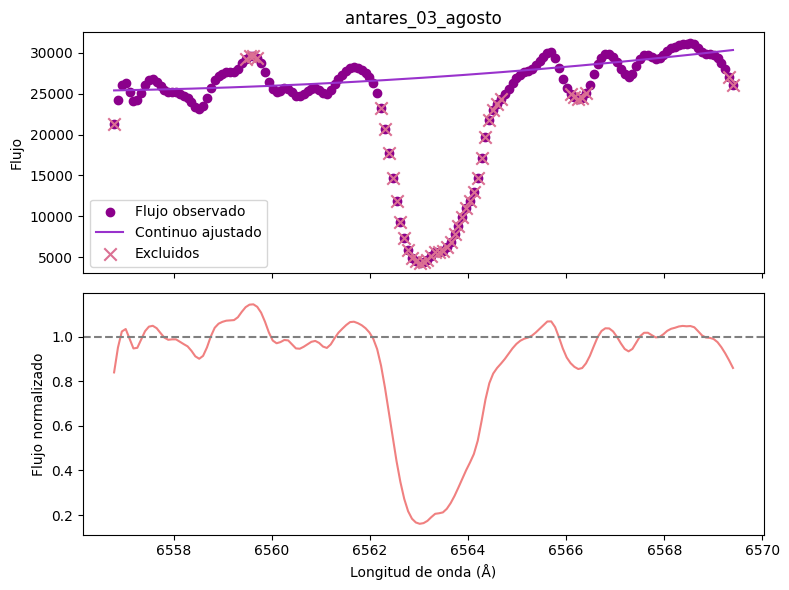


Procesando: antares_07_agosto
  Puntos totales: 162
  Puntos excluidos: 54
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_07_agosto_control.png


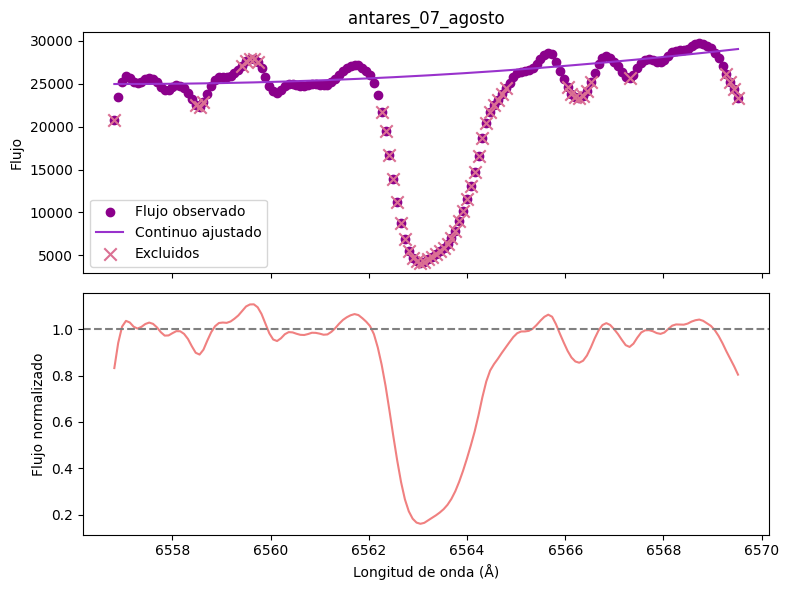


Procesando: antares_11_agosto
  Puntos totales: 163
  Puntos excluidos: 62
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_11_agosto_control.png


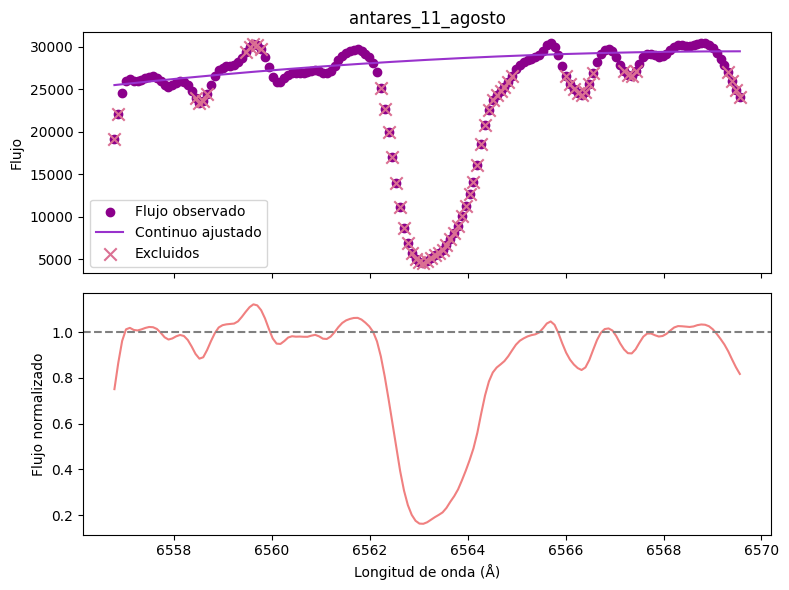


Procesando: antares_16_agosto
  Puntos totales: 163
  Puntos excluidos: 61
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_16_agosto_control.png


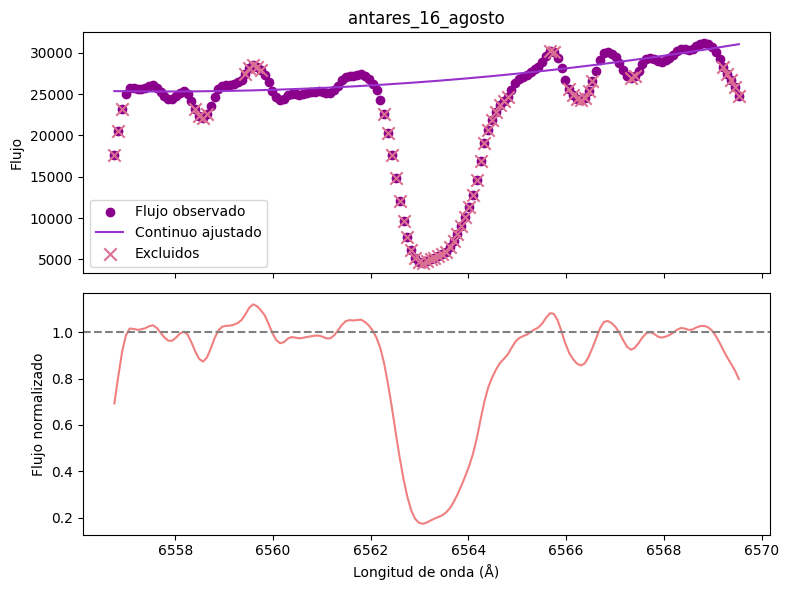


Procesando: antares_23_agosto
  Puntos totales: 162
  Puntos excluidos: 52
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_23_agosto_control.png


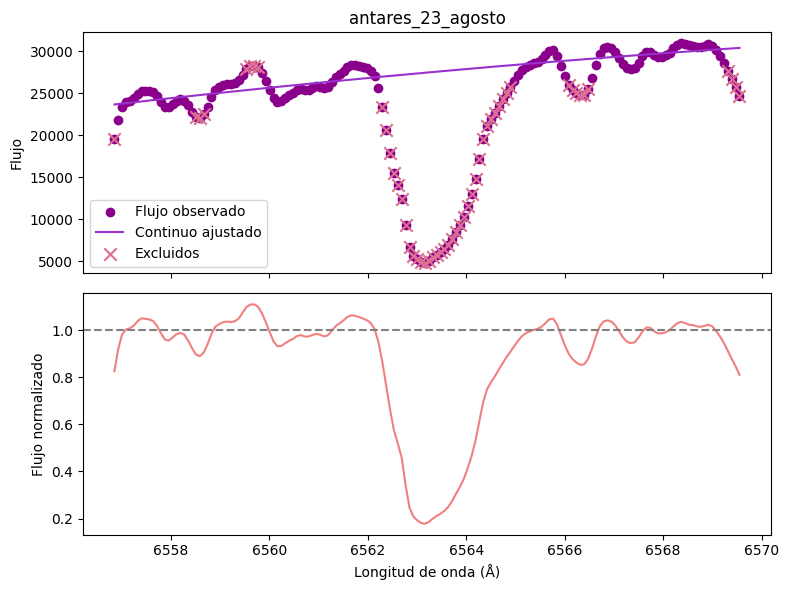


Procesando: antares_29_agosto
  Puntos totales: 206
  Puntos excluidos: 83
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_29_agosto_control.png


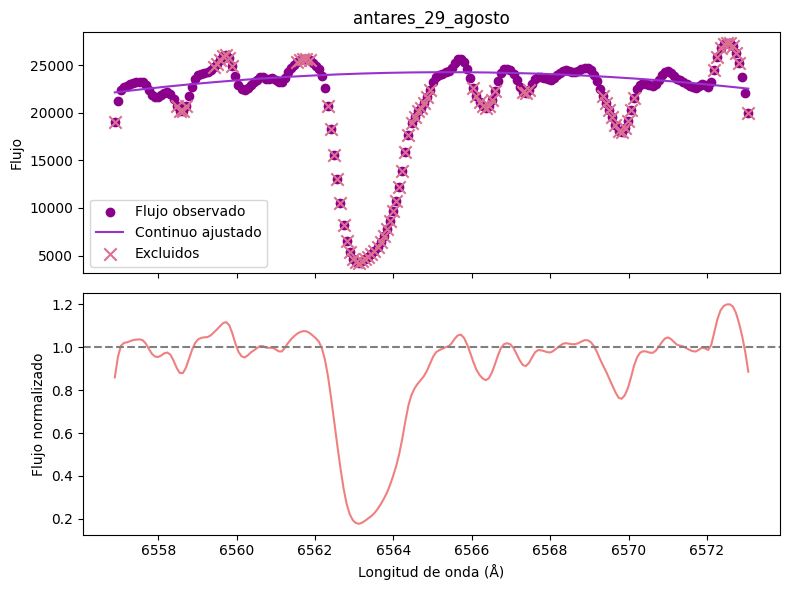


Procesando: antares_11_septiembre
  Puntos totales: 208
  Puntos excluidos: 64
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_11_septiembre_control.png


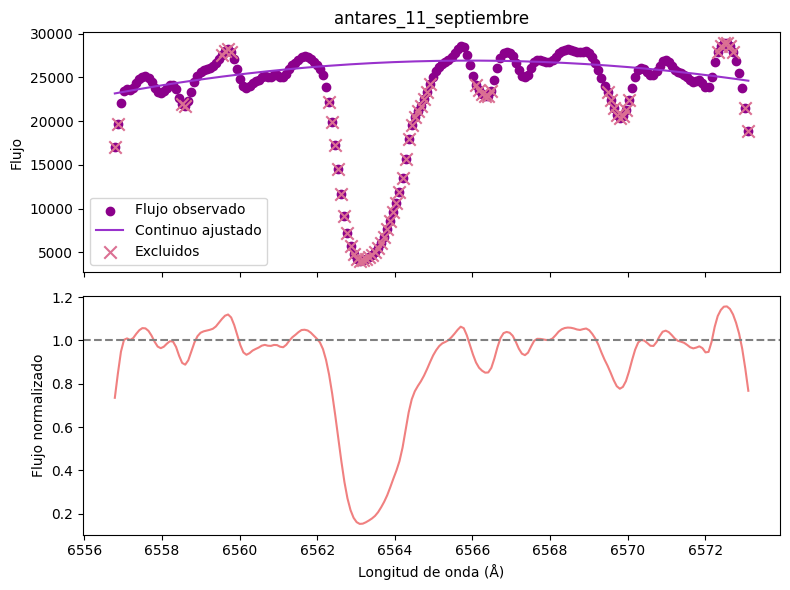


Proceso completo.


In [22]:
if guardar_graficos:
    Path(carpeta_graficos).mkdir(exist_ok=True)
 
for nombre, df in espectros.items():
    print(f"\nProcesando: {nombre}")
 
    longitud_onda = df[col_longitud_onda].values
    flujo = df[col_flujo].values
 
    continuo, mascara_continuo = ajustar_continuo(longitud_onda, flujo, grado_polinomio, N_iteraciones, sigma_corte)

    df["Continuo ajustado"] = continuo
    df["Flujo normalizado"] = flujo / continuo
    df["Usado en ajuste"] = mascara_continuo

    print(f"  Puntos totales: {len(mascara_continuo)}")
    print(f"  Puntos excluidos: {(~mascara_continuo).sum()}")

    mascara_bool = np.asarray(mascara_continuo, dtype=bool)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
 
    ax1.scatter(longitud_onda, flujo, color = "darkmagenta", label="Flujo observado")
    ax1.plot(longitud_onda, continuo, color ="darkorchid", label="Continuo ajustado")
    ax1.scatter(longitud_onda[~mascara_bool], flujo[~mascara_bool], color = "palevioletred",marker = "x", label="Excluidos", s = 80)
    ax1.set_ylabel("Flujo")
    ax1.legend()
    ax1.set_title(nombre)
 
    ax2.plot(longitud_onda, df["Flujo normalizado"], color ="lightcoral")
    ax2.axhline(1.0, color="gray", linestyle="--")
    ax2.set_ylabel("Flujo normalizado")
    ax2.set_xlabel("Longitud de onda (Å)")
 
    plt.tight_layout()
 
    if guardar_graficos:
        fig_path = Path(carpeta_graficos) / f"{nombre}_control.png"
        plt.savefig(fig_path, dpi=120)
        print(f"  -> Gráfico guardado: {fig_path}")
 
    plt.show()
    plt.close(fig)
 
print("\nProceso completo.")

<h3 style="color: #e19edc;"> Obtención del perfil de absorción y emisión de la línea H<sub>&alpha;</sub></h3>

<h4 style="color: #e19edc;"> Teniendo en cuenta las posibles mezclas con las líneas de absorción</h4>

In [23]:
c_kms_s = 299792.458

def efecto_doppler(longitud_lab, velocidad_kms):
    return longitud_lab * (1 + velocidad_kms / c_kms_s)

def velocidad_desde_doppler(longitud_lab, longitud_obs):
    return c_kms_s * (longitud_obs / longitud_lab - 1)


def profundidad_interpolada(teff, t_ref=(3500, 4250), prof_ref=(0.55, 0.63)):
    return float(np.interp(teff, t_ref, prof_ref))


def amplitud_desde_profundidad(profundidad, continuo_local, sigma, gamma):
    z = 1j * gamma / (sigma * np.sqrt(2))
    pico_unitario = wofz(z).real / (sigma * np.sqrt(2 * np.pi))
    return -profundidad * continuo_local / pico_unitario

In [25]:
#MODELO DE AJUSTE

def construccion_del_modelo(lineas_metalicas=None):
    continuo = ConstantModel(prefix="cont_")
    em_azul = VoigtModel(prefix="em_azul_")
    valle_abs = VoigtModel(prefix="valle_abs_")
    modelo = continuo + em_azul + valle_abs

    if lineas_metalicas:
        for linea in lineas_metalicas:
            modelo += VoigtModel(prefix=f"{linea['nombre']}_")

    return modelo

def encontrar_parametros(modelo, longitud_onda, flujo, centro_aprox, lineas_metalicas, teff=3660):
    p = modelo.make_params()

    borde = np.r_[flujo[:5], flujo[-5:]]
    continuo_local = float(np.median(borde))
    p["cont_c"].set(value=continuo_local, min=0, max=2)

    izquierda = longitud_onda < centro_aprox

    # Emisión azul
    i_azul = np.argmax(flujo[izquierda])
    p["em_azul_center"].set(value=longitud_onda[izquierda][i_azul], min=longitud_onda.min(), max=centro_aprox)
    p["em_azul_amplitude"].set(value=1.0, min=0)
    p["em_azul_sigma"].set(value=0.4, min=0.05, max=2)

    # Absorción central
    i_min = np.argmin(flujo)
    p["valle_abs_center"].set(value=longitud_onda[i_min], min=centro_aprox - 1, max=centro_aprox + 1)
    p["valle_abs_amplitude"].set(value=-(continuo_local - flujo[i_min]) * 1.5, max=0)
    p["valle_abs_sigma"].set(value=0.3, min=0.03, max=1.2)
    p["valle_abs_gamma"].set(value=0.2, min=0, max=1.2, vary=True)

    # Líneas metálicas: Doppler + profundidad física
    if lineas_metalicas:
        for linea in lineas_metalicas:
            pref = f"{linea['nombre']}_"
            c0_lab = linea["centro"]

            centro_libre = linea.get("centro_libre", False)

            if centro_libre:
                # No hay ninguna velocidad de referencia
                margen_v_libre = linea.get("margen_v_libre", 23.5)  # km/s. La velocidad está basada en las velocidades de los espectros
                margen_aa = c0_lab * margen_v_libre / c_kms_s
                valor_inicial = linea.get("centro_inicial", c0_lab)
                p[f"{pref}center"].set(
                    value=valor_inicial,
                    min=c0_lab - margen_aa,
                    max=c0_lab + margen_aa,
                )
            else:
                # Corrimiento Doppler propio de la época
                v = linea.get("velocidad", 0.0)
                c0_obs = efecto_doppler(c0_lab, v)
                margen_v = linea.get("incertidumbre_v", 3.0)
                margen_aa = c0_lab * margen_v / c_kms_s
                p[f"{pref}center"].set(value=c0_obs, min=c0_obs - margen_aa, max=c0_obs + margen_aa)

            # Ancho inicial
            sigma0 = linea.get("sigma_inicial", 0.12)
            gamma0 = linea.get("gamma_inicial", 0.05)
            p[f"{pref}sigma"].set(value=sigma0, min=0.02, max=0.4)
            p[f"{pref}gamma"].set(value=gamma0, min=0, max=0.3, vary=True)

            # Profundidad física según Teff
            prof = linea.get("profundidad")  
            if prof is None:
                prof = profundidad_interpolada(
                    teff, t_ref=linea.get("t_ref", (3500, 4250)), prof_ref=linea.get("prof_ref", (0.55, 0.63)),
                )
            amp0 = amplitud_desde_profundidad(prof, continuo_local, sigma0, gamma0)
            p[f"{pref}amplitude"].set(value=amp0, min=amp0 * 1.8, max=0)

    return p

In [26]:
# DESCOMPOSICIÓN DE "PERFILES"

def fit_y_decomposicion(datos_cercanos, centro_aprox, longitud_observada, flujo_normalizado,
                         lineas_metalicas=None, teff=3660):
    longitud_onda = datos_cercanos[longitud_observada].to_numpy()
    flujo = datos_cercanos[flujo_normalizado].to_numpy()

    modelo = construccion_del_modelo(lineas_metalicas)
    parametros = encontrar_parametros(modelo, longitud_onda, flujo, centro_aprox,
                                       lineas_metalicas, teff=teff)
    fit = modelo.fit(flujo, parametros, x=longitud_onda)

    comps = fit.eval_components(x=longitud_onda)
    continuo = comps["cont_"]

    perfil_emision = continuo + comps["em_azul_"]
    perfil_absorcion = continuo + comps["valle_abs_"]
    residuo = flujo - fit.best_fit

    return dict(longitud_onda = longitud_onda, flujo = flujo, fit = fit, comps = comps, perfil_emision = perfil_emision,
                perfil_absorcion = perfil_absorcion, residuo=residuo)

In [27]:
# VISUALIZACIÓN

def visualizacion_con_metalica(res_metal, lineas_metalicas, mes, titulo,):
    longitud_onda, flujo, fit = res_metal["longitud_onda"], res_metal["flujo"], res_metal["fit"]
    comps = res_metal["comps"]
    continuo = comps["cont_"]

    fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                              gridspec_kw={"height_ratios": [2.2, 1]})

    ax = axes[0]
    ax.scatter(longitud_onda, flujo, s=18, color="darkcyan", label="Observado", zorder=3)
    ax.plot(longitud_onda, fit.best_fit, color="lightseagreen", lw=1.8, label="Modelo total")
    ax.plot(longitud_onda, res_metal["perfil_emision"], "--", color="turquoise", lw=1.3,
            label="Perfil de emisión")
    ax.plot(longitud_onda, res_metal["perfil_absorcion"], "--", color="deepskyblue", lw=1.3,
            label=r"Perfil de absorción $H_\alpha$")

    for linea in lineas_metalicas:
        pref = f"{linea['nombre']}_"
        perfil_metal = continuo + comps[pref]
        ax.plot(longitud_onda, perfil_metal, "-.", color="purple", lw=1.3,
                label=f"Componente {linea['nombre']}")
        ax.axvline(fit.params[f"{pref}center"].value, color="orchid",
                   lw=0.7, ls=":", alpha=0.5)

    ax.axhline(continuo[0], color="gray", lw=0.7, ls=":")
    ax.set_ylabel("Flujo normalizado")
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    ax2 = axes[1]
    ax2.plot(longitud_onda, res_metal["residuo"], color="black", lw=1)
    ax2.axhline(0, color="gray", lw=0.7)
    ax2.set_xlabel("Longitud de onda [Å]")
    ax2.set_ylabel("Residuo")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(fr"Graficas 2018\halpha_{mes.lower()}_cobalto.png", dpi=150)
    plt.show()

In [28]:
def velocidad_desde_centro_libre(fit, nombre_linea, centro_lab):
    centro_obs = fit.params[f"{nombre_linea}_center"].value
    centro_obs_err = fit.params[f"{nombre_linea}_center"].stderr
    v = velocidad_desde_doppler(centro_lab, centro_obs)
    v_err = c_kms_s * centro_obs_err / centro_lab if centro_obs_err is not None else None
    return v, v_err

def comparar_velocidades(v_ajustada, v_ajustada_err, velocidades_referencia, nombres_referencia=None):
    
    if nombres_referencia is None:
        nombres_referencia = [f"Referencia {i+1}" for i in range(len(velocidades_referencia))]

    texto_v = f"{v_ajustada:.2f}" + (f" ± {v_ajustada_err:.2f}" if v_ajustada_err else "")
    print(f"Velocidad óptima (ajuste, centro libre): {texto_v} km/s")

    for nombre, v_ref in zip(nombres_referencia, velocidades_referencia):
        diff = v_ajustada - v_ref
        print(f"  vs {nombre} = {v_ref:.2f} km/s  ->  Δv = {diff:+.2f} km/s")

In [29]:
#Falta hallar verdaderamente el centro

metadatos = {
    "antares_24_julio": {
        "centro_aprox": 6562.994,
        "velocidad_visible": 19.4,
        "velocidad_infrarrojo": 19.76,
        "incertidumbre_v": 0.7,
    },
    "antares_27_julio": {
        "centro_aprox": 6563.045,
        "velocidad_visible": 20.2,
        "incertidumbre_v": 0.8,
    },
    "antares_03_agosto": {
        "centro_aprox": 6563.015,
        "velocidad_visible": 23,
        "velocidad_infrarrojo": 23.5,
        "incertidumbre_v": 0.9,
    },
    "antares_07_agosto": {
        "centro_aprox": 6563.05116,
        "velocidad_visible": 23.9,
        "velocidad_infrarrojo": 24.1,
        "incertidumbre_v": 0.5,
    },
    "antares_11_agosto": {
        "centro_aprox": 6563.091,
        "velocidad_visible": 24.9,
        "incertidumbre_v": 0.7,
    },
    "antares_16_agosto": {
        "centro_aprox": 6563.067,
        "velocidad_visible": 25.1,
        "velocidad_infrarrojo": 25.8,
        "incertidumbre_v": 0.4,
    },
    "antares_23_agosto": {
        "centro_aprox": 6563.164,
        "velocidad_visible": 26,
        "velocidad_infrarrojo": 26.18,
        "incertidumbre_v": 0.11,
    },
    "antares_29_agosto": {
        "centro_aprox": 6563.131,
        "velocidad_visible": 26.3,
        "velocidad_infrarrojo": 27.09,
        "incertidumbre_v": 0.15,
    },
    "antares_11_septiembre": {
        "centro_aprox": 6563.095,
        "velocidad_visible": 26,
        "velocidad_infrarrojo": 26.75,
        "incertidumbre_v": 0.5,
    },
}


antares_24_julio
  chi2 (fijo)  = 0.7492
  chi2 (libre) = 0.8994
Velocidad óptima (ajuste, centro libre): 6.03 ± 17680886558.95 km/s
  vs Línea metálica (visible) = 19.40 km/s  ->  Δv = -13.37 km/s
  vs Línea metálica (infrarrojo) = 19.76 km/s  ->  Δv = -13.73 km/s


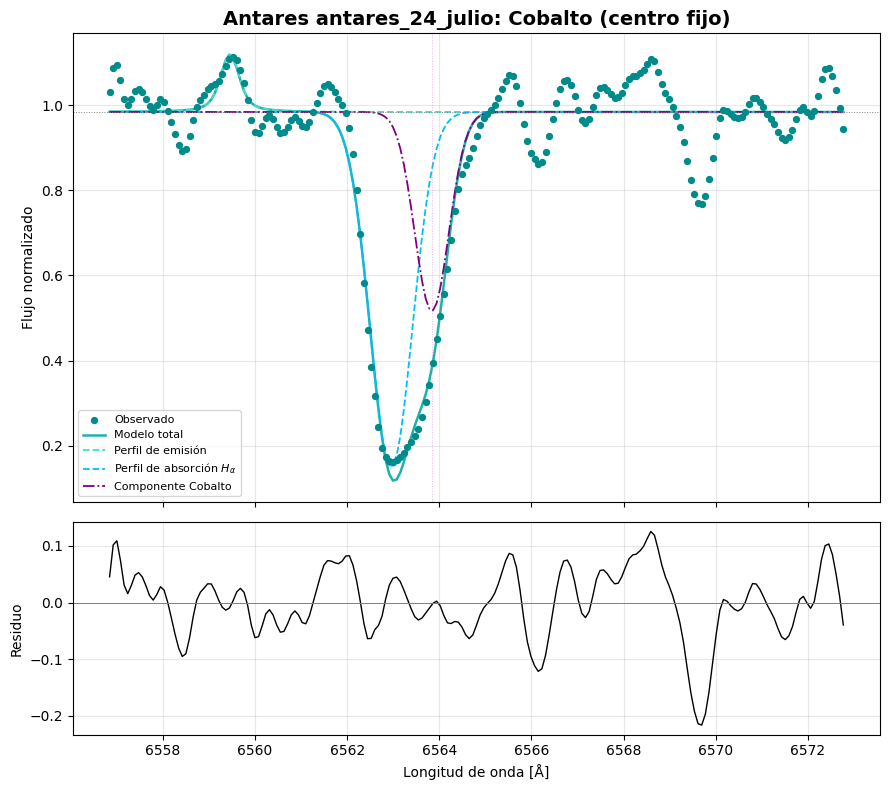

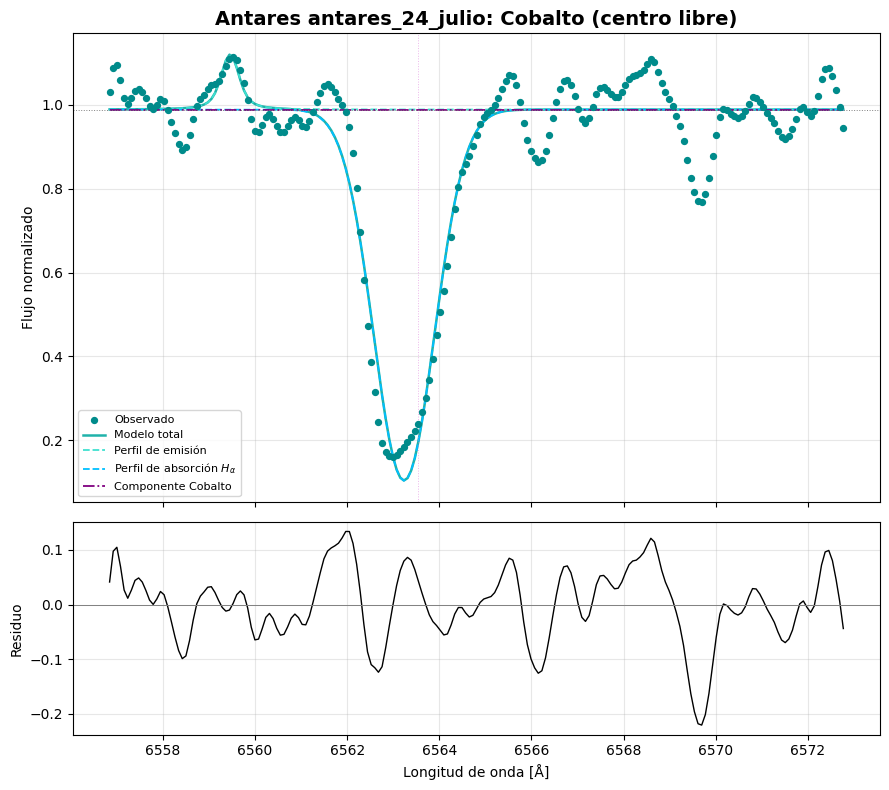


antares_27_julio
  chi2 (fijo)  = 0.3888
  chi2 (libre) = 0.5602
Velocidad óptima (ajuste, centro libre): 7.09 km/s
  vs Línea metálica (visible) = 20.20 km/s  ->  Δv = -13.11 km/s


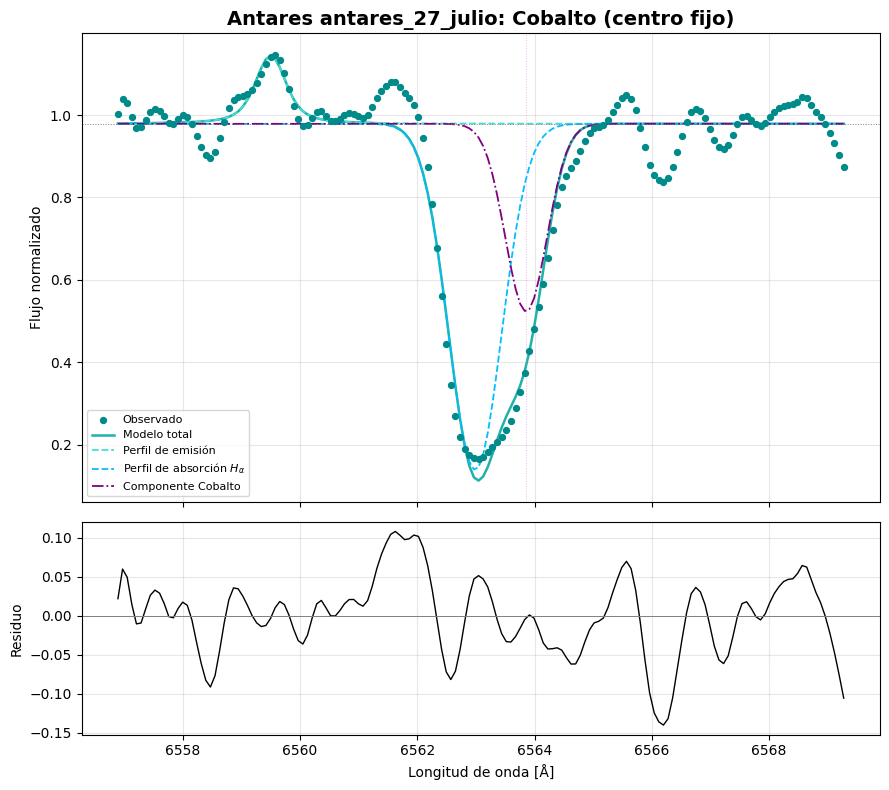

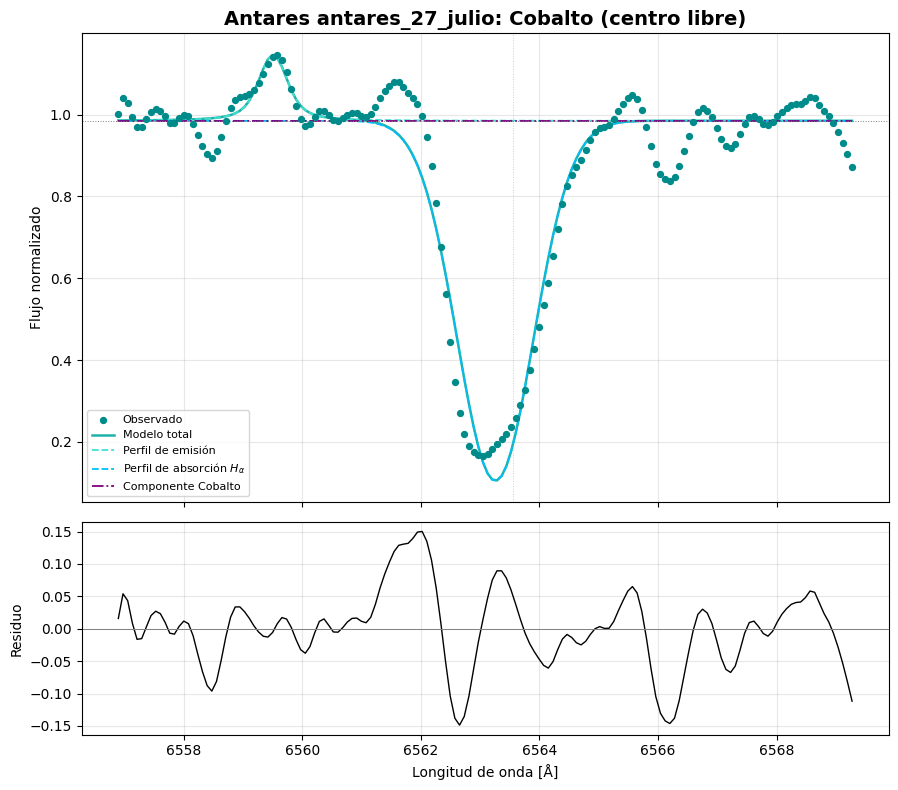


antares_03_agosto
  chi2 (fijo)  = 0.4275
  chi2 (libre) = 0.6132
Velocidad óptima (ajuste, centro libre): -2.08 km/s
  vs Línea metálica (visible) = 23.00 km/s  ->  Δv = -25.08 km/s
  vs Línea metálica (infrarrojo) = 23.50 km/s  ->  Δv = -25.58 km/s


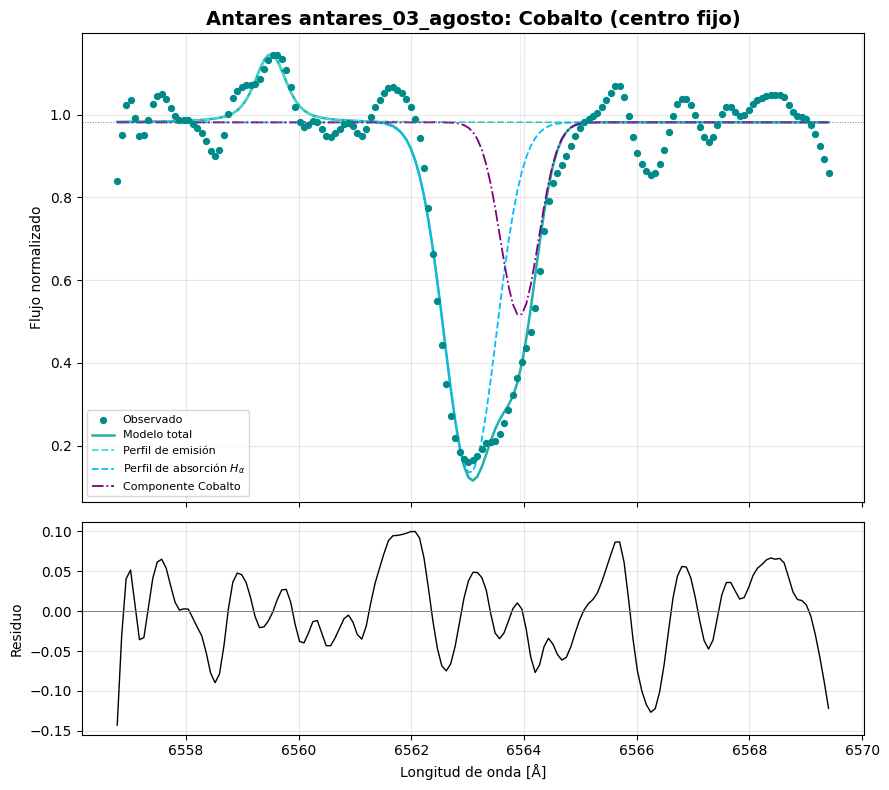

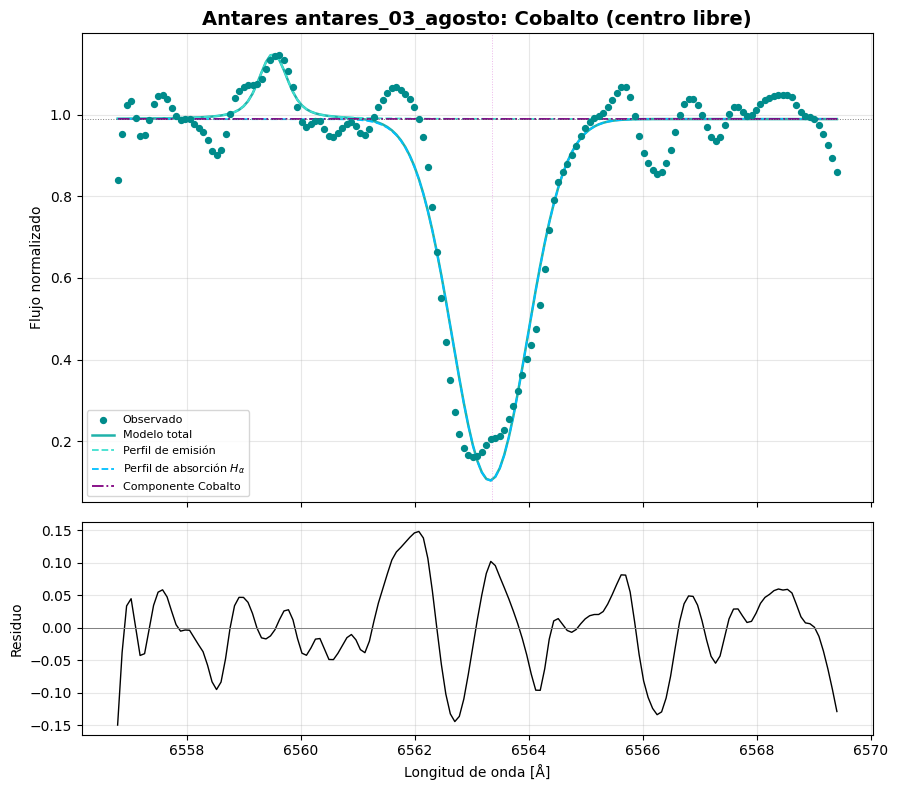


antares_07_agosto
  chi2 (fijo)  = 0.4025
  chi2 (libre) = 0.5686
Velocidad óptima (ajuste, centro libre): 3.25 ± 771298365.14 km/s
  vs Línea metálica (visible) = 23.90 km/s  ->  Δv = -20.65 km/s
  vs Línea metálica (infrarrojo) = 24.10 km/s  ->  Δv = -20.85 km/s


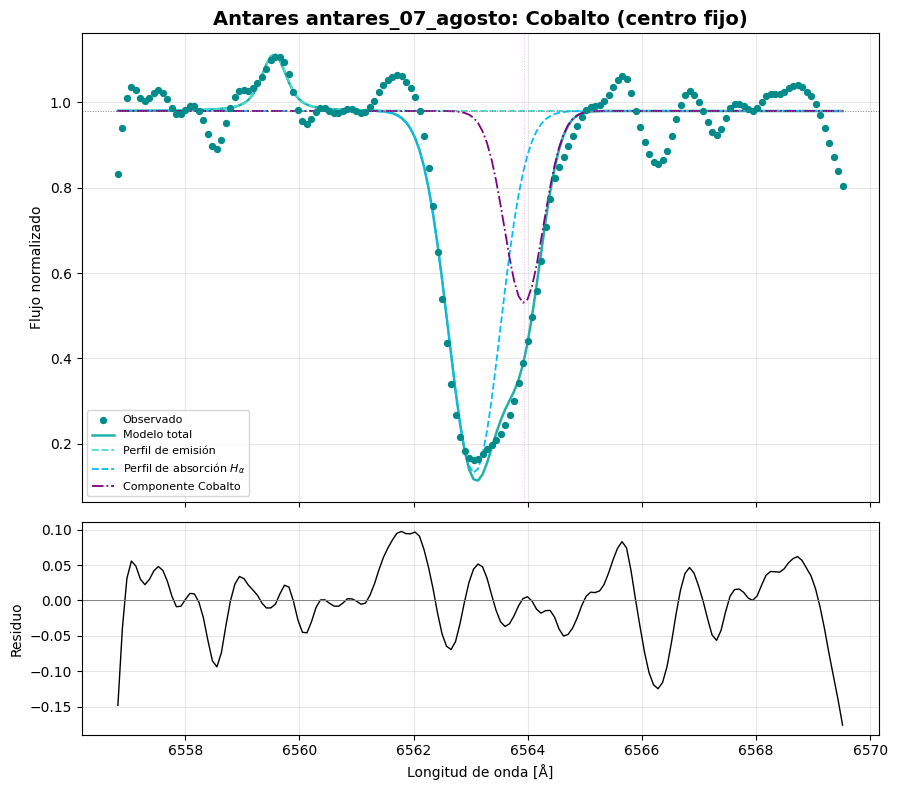

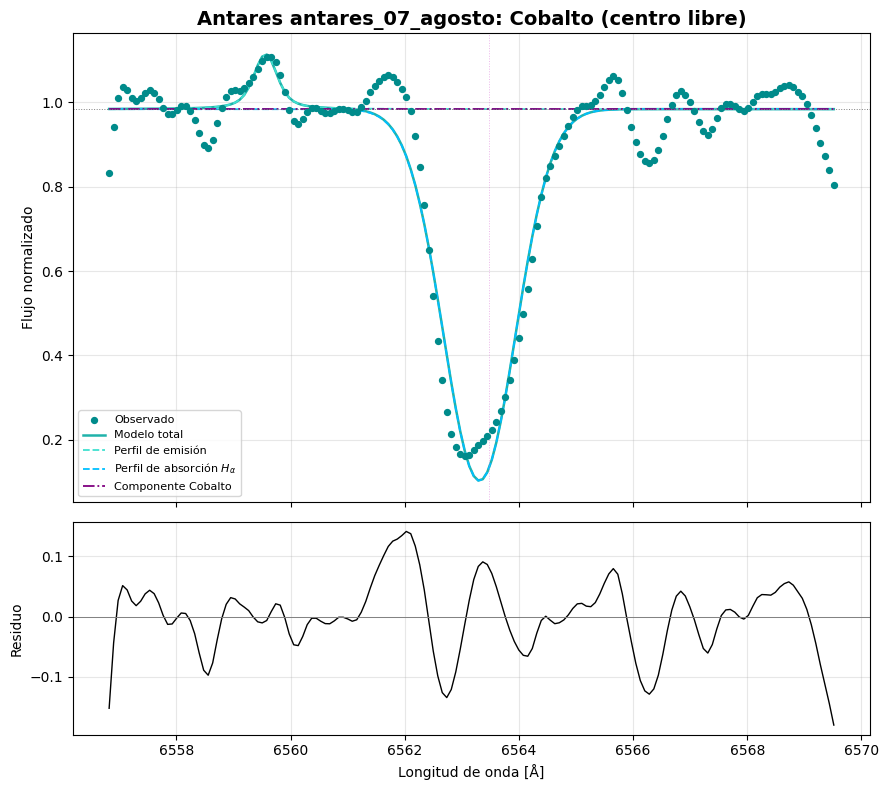


antares_11_agosto
  chi2 (fijo)  = 0.4748
  chi2 (libre) = 0.6435
Velocidad óptima (ajuste, centro libre): -0.79 ± 934319943.65 km/s
  vs Línea metálica (visible) = 24.90 km/s  ->  Δv = -25.69 km/s


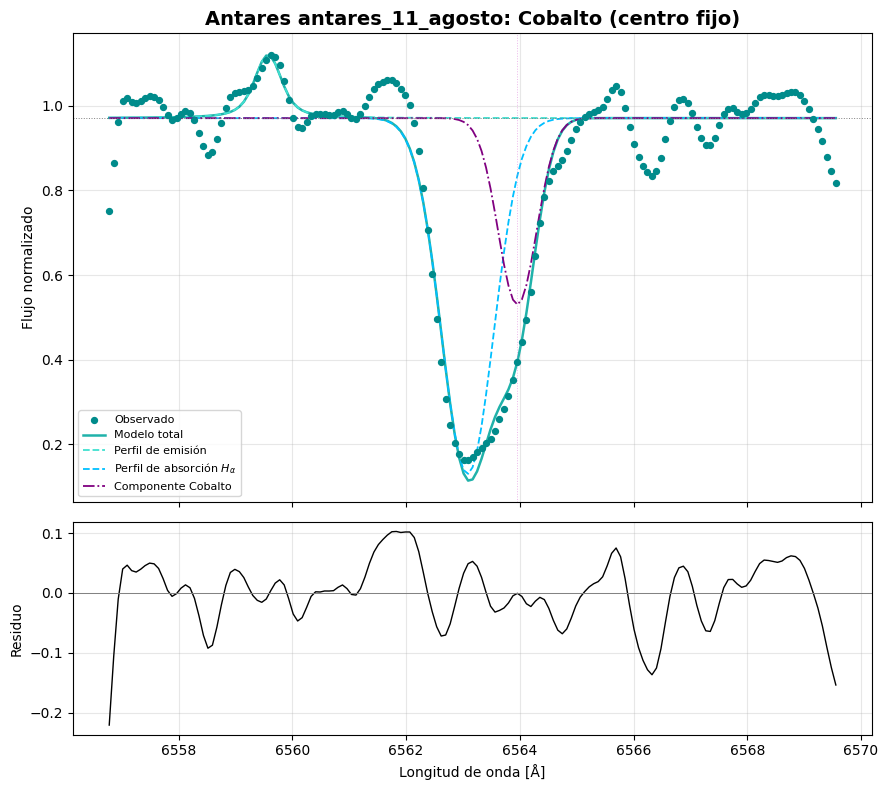

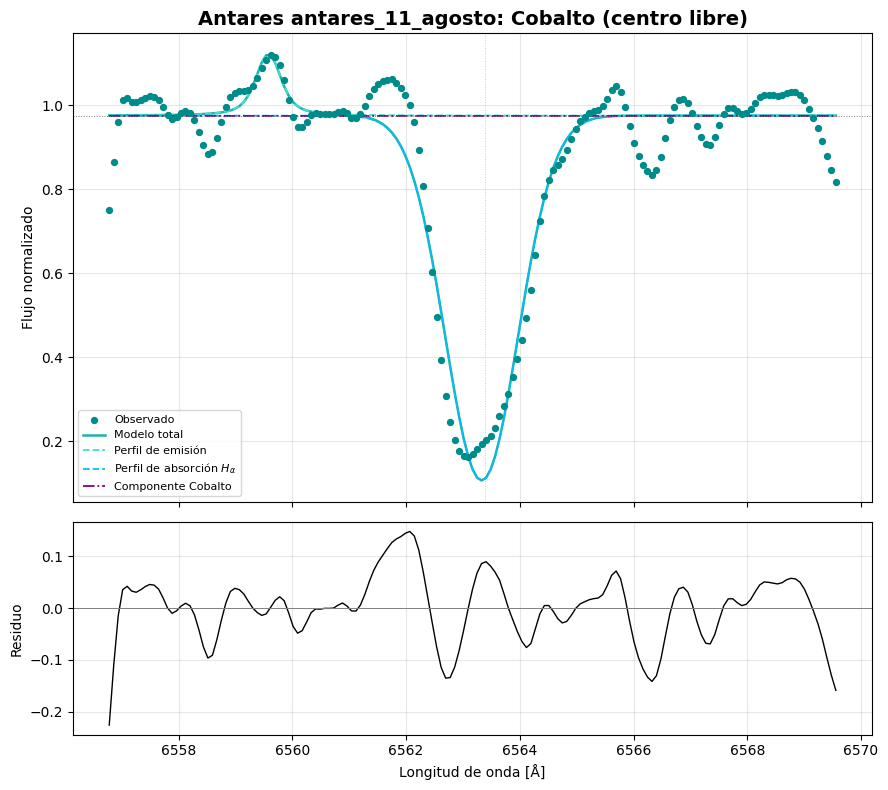


antares_16_agosto
  chi2 (fijo)  = 0.5219
  chi2 (libre) = 0.6732
Velocidad óptima (ajuste, centro libre): 0.12 ± 99444513.56 km/s
  vs Línea metálica (visible) = 25.10 km/s  ->  Δv = -24.98 km/s
  vs Línea metálica (infrarrojo) = 25.80 km/s  ->  Δv = -25.68 km/s


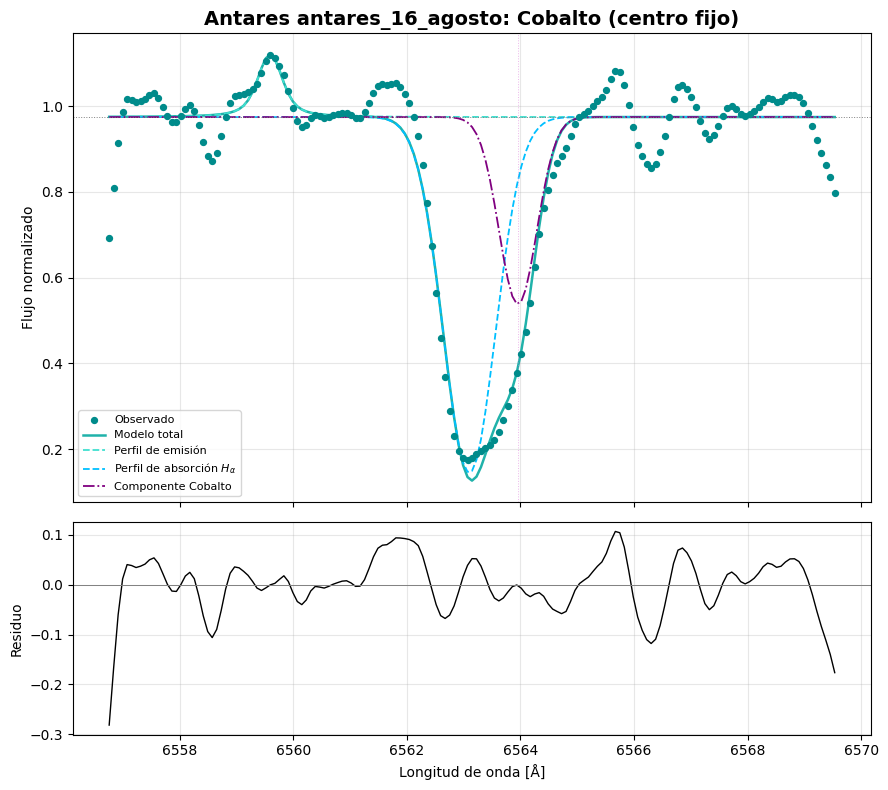

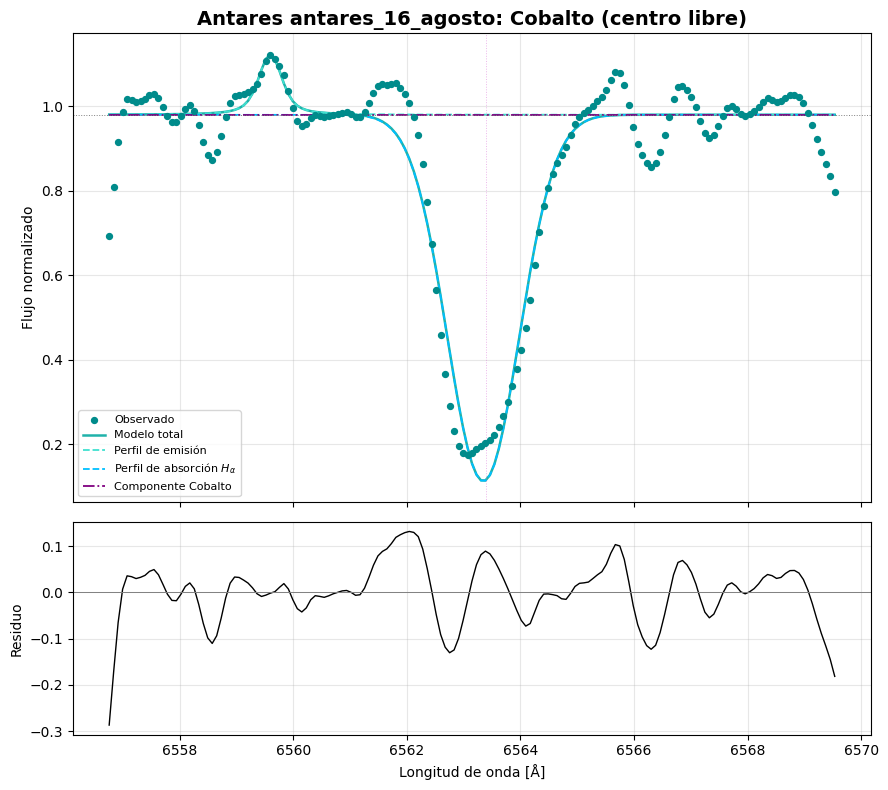


antares_23_agosto
  chi2 (fijo)  = 0.4426
  chi2 (libre) = 0.5695
Velocidad óptima (ajuste, centro libre): -2.01 ± 2605412872.59 km/s
  vs Línea metálica (visible) = 26.00 km/s  ->  Δv = -28.01 km/s
  vs Línea metálica (infrarrojo) = 26.18 km/s  ->  Δv = -28.19 km/s


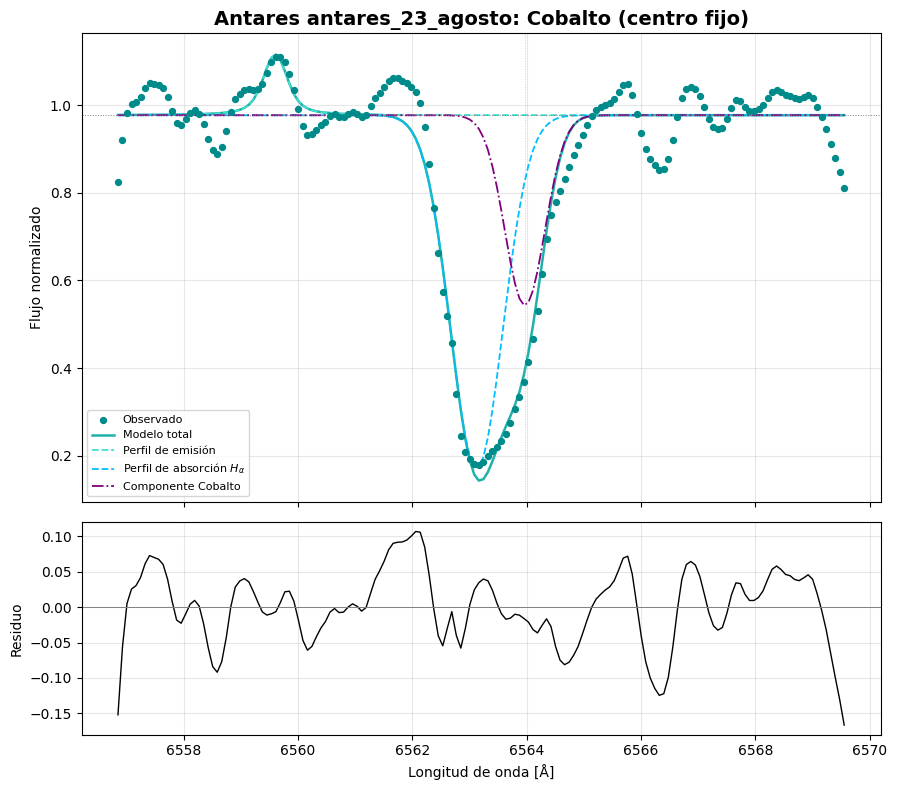

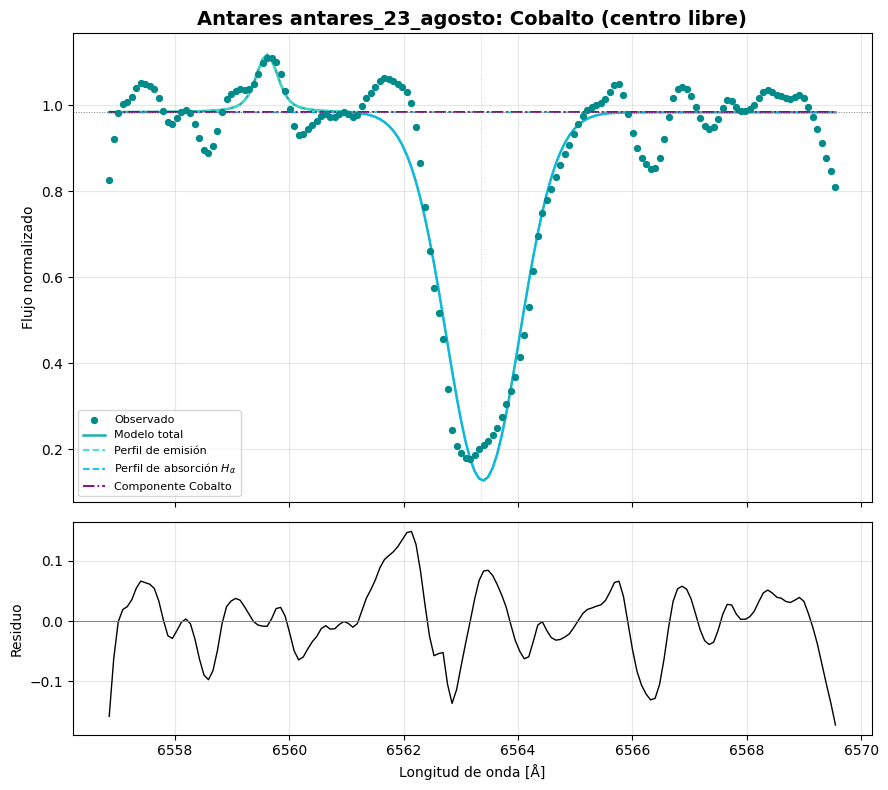


antares_29_agosto
  chi2 (fijo)  = 1.0052
  chi2 (libre) = 1.1838
Velocidad óptima (ajuste, centro libre): -1.28 ± 10278843186.59 km/s
  vs Línea metálica (visible) = 26.30 km/s  ->  Δv = -27.58 km/s
  vs Línea metálica (infrarrojo) = 27.09 km/s  ->  Δv = -28.37 km/s


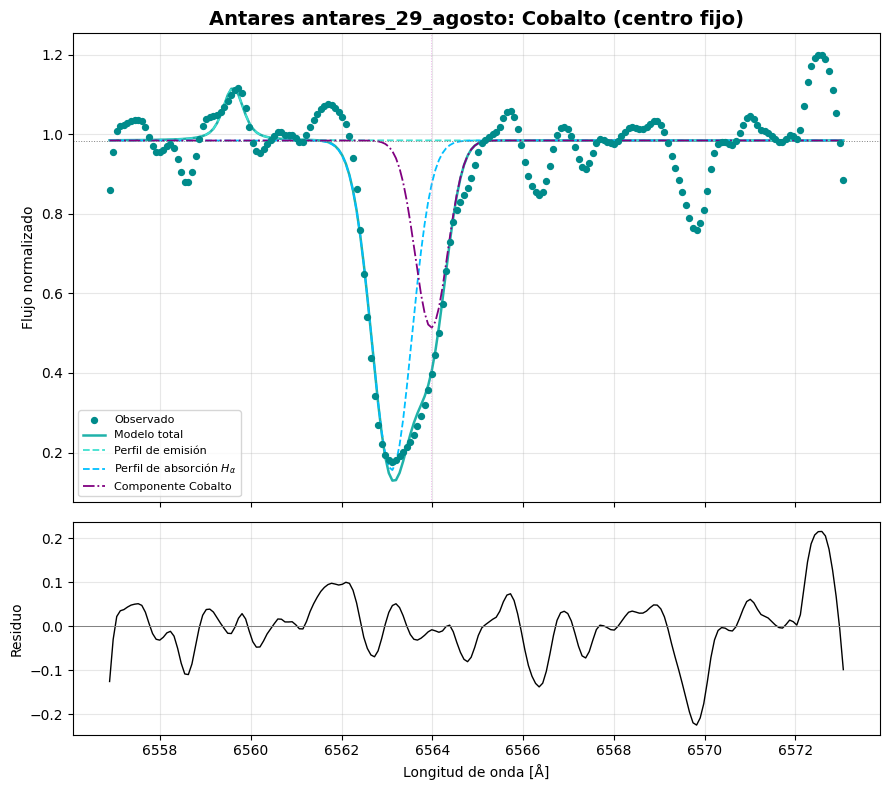

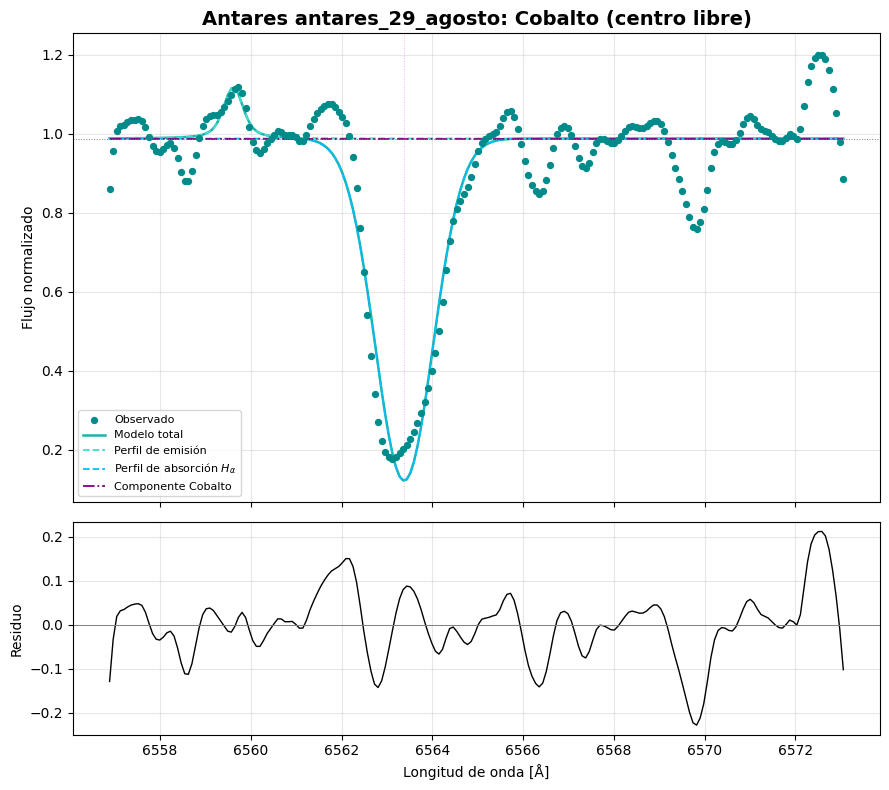


antares_11_septiembre
  chi2 (fijo)  = 0.9577
  chi2 (libre) = 1.0813
Velocidad óptima (ajuste, centro libre): -0.33 ± 476711701.78 km/s
  vs Línea metálica (visible) = 26.00 km/s  ->  Δv = -26.33 km/s
  vs Línea metálica (infrarrojo) = 26.75 km/s  ->  Δv = -27.08 km/s


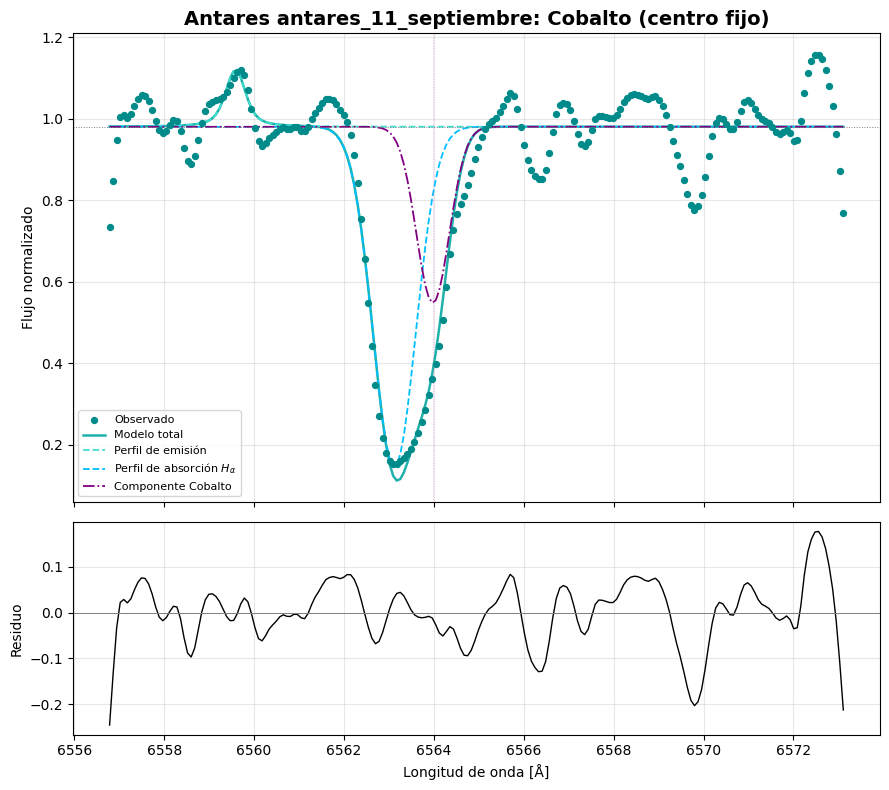

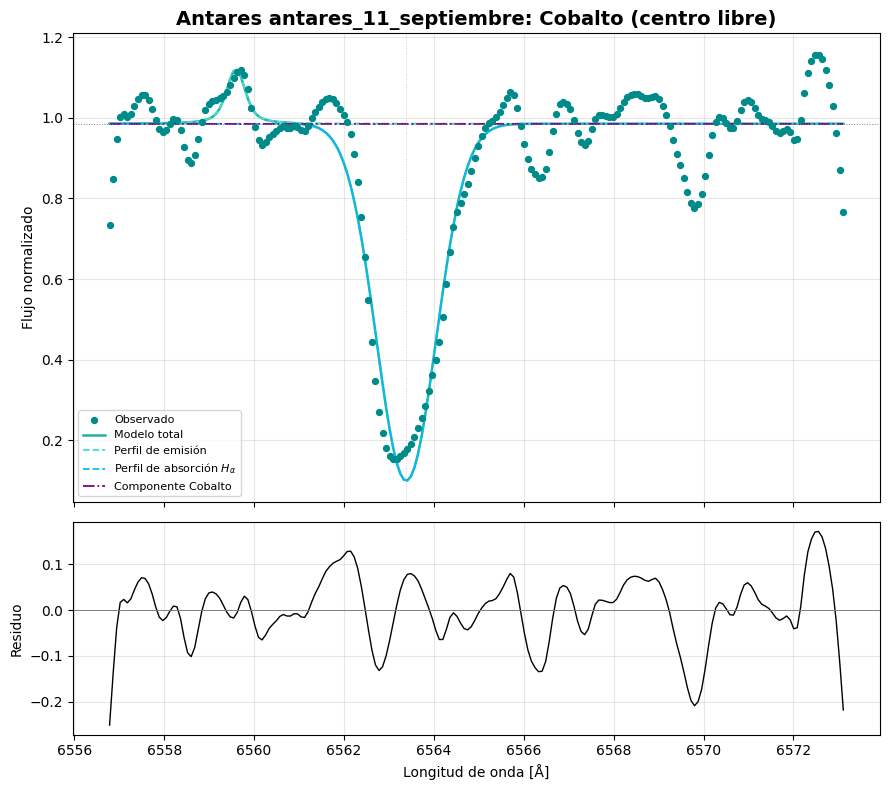

In [33]:
resultados = {}
centro_lab_cobalto = 6563.397

for nombre, datos in espectros.items():
    meta = metadatos[nombre]

    # Ajuste 1: Centro Fijo
    lineas_fijo = [
        {
            "nombre": "Cobalto",
            "centro": centro_lab_cobalto,
            "ion": "Co I",
            "velocidad": meta["velocidad_visible"],
            "incertidumbre_v": meta["incertidumbre_v"],
            "prof_ref": (0.55, 0.63),
            "t_ref": (3500, 4250),
        }
    ]
    res_fijo = fit_y_decomposicion(datos, meta["centro_aprox"], "Longitud onda", "Flujo normalizado",
                                    lineas_metalicas=lineas_fijo, teff=3660)

    # Ajuste 2: Centro Libre
    lineas_libre = [
        {
            "nombre": "Cobalto",
            "centro": centro_lab_cobalto,
            "ion": "Co I",
            "centro_libre": True,
            "margen_v_libre": 60.0,
            "prof_ref": (0.55, 0.63),
            "t_ref": (3500, 4250),
        }
    ]
    res_libre = fit_y_decomposicion(datos, meta["centro_aprox"], "Longitud onda", "Flujo normalizado",
                                     lineas_metalicas=lineas_libre, teff=3660)

    resultados[nombre] = {"fijo": res_fijo, "libre": res_libre}

    # --- Comparación ---
    v_opt, v_opt_err = velocidad_desde_centro_libre(res_libre["fit"], "Cobalto", centro_lab_cobalto)

    print(f"\n{nombre}")
    print(f"  chi2 (fijo)  = {res_fijo['fit'].chisqr:.4f}")
    print(f"  chi2 (libre) = {res_libre['fit'].chisqr:.4f}")
    # Construye la lista de referencias solo con las que existan para este espectro
    refs_disponibles = []
    nombres_disponibles = []

    if meta.get("velocidad_visible") is not None:
        refs_disponibles.append(meta["velocidad_visible"])
        nombres_disponibles.append("Línea metálica (visible)")

    if meta.get("velocidad_infrarrojo") is not None:
        refs_disponibles.append(meta["velocidad_infrarrojo"])
        nombres_disponibles.append("Línea metálica (infrarrojo)")

    if refs_disponibles:
        comparar_velocidades(
            v_opt, v_opt_err,
            velocidades_referencia=refs_disponibles,
            nombres_referencia=nombres_disponibles,
        )
    else:
        print("  (Sin velocidades de referencia disponibles para comparar)")

    # --- Visualización ---
    visualizacion_con_metalica(res_fijo, lineas_fijo, nombre,
                                titulo=f"Antares {nombre}: Cobalto (centro fijo)")
    visualizacion_con_metalica(res_libre, lineas_libre, nombre,
                                titulo=f"Antares {nombre}: Cobalto (centro libre)")